In [1]:
# 1. LOAD DATA & INITIAL ANALYSIS
print("🚀 STEP 1: Loading Original + Generated Grids")
print("=" * 50)

import numpy as np
import matplotlib.pyplot as plt
from utils.data_loading import DataLoader

# Load data
data_loader = DataLoader()

# Load generated grids
generated_grids, generated_predictions = data_loader.load_generated_grids()

# Load original grids  
original_grids, original_predictions = data_loader.load_original_grids()

print(f"📊 Data loaded:")
if original_grids is not None:
    print(f"   Original grids: {len(original_grids):,}")
if generated_grids is not None:
    print(f"   Generated grids: {len(generated_grids):,}")

🚀 STEP 1: Loading Original + Generated Grids
   Loading generated: c:\Users\Lenovo\2156_cp2\data\generated_grids\combined_constraint_free_grids_20251103_023328.npy
✅ Loaded predictions from: combined_constraint_free_predictions_20251103_023328.npy
✅ Loaded 60,000 generated grids
✅ Loaded predictions: (60000, 4)
✅ Loaded 500,000 original grids from 5 files
✅ Loaded oracle predictions: (500000, 4)
📊 Data loaded:
   Original grids: 500,000
   Generated grids: 60,000
   Loading generated: c:\Users\Lenovo\2156_cp2\data\generated_grids\combined_constraint_free_grids_20251103_023328.npy
✅ Loaded predictions from: combined_constraint_free_predictions_20251103_023328.npy
✅ Loaded 60,000 generated grids
✅ Loaded predictions: (60000, 4)
✅ Loaded 500,000 original grids from 5 files
✅ Loaded oracle predictions: (500000, 4)
📊 Data loaded:
   Original grids: 500,000
   Generated grids: 60,000


In [2]:
# Filter by threshold

THRESHOLD = 0.75

# Handle original grids
if original_grids is not None and original_predictions is not None:
    original_min_scores = np.min(original_predictions, axis=1)
    valid_original = original_grids[original_min_scores >= THRESHOLD]
    print(f"✅ Valid original grids: {len(valid_original):,}")
else:
    valid_original = np.array([])
    print("⚠️  No original grids available")

# Handle generated grids
if generated_grids is not None and generated_predictions is not None:
    generated_min_scores = np.min(generated_predictions, axis=1)
    valid_generated = generated_grids[generated_min_scores >= THRESHOLD]
    print(f"✅ Valid generated grids: {len(valid_generated):,}")
else:
    valid_generated = np.array([])
    print("⚠️  No generated grids or predictions available")

print(f"\n📊 Summary:")
print(f"   Threshold: {THRESHOLD}")
print(f"   Valid original grids: {len(valid_original):,}")
print(f"   Valid generated grids: {len(valid_generated):,}")


✅ Valid original grids: 693
✅ Valid generated grids: 34

📊 Summary:
   Threshold: 0.75
   Valid original grids: 693
   Valid generated grids: 34


📊 District Frequency Heatmap Analysis

1️⃣ ORIGINAL VALID GRIDS:
🔍 Analyzing position frequencies for 693 original valid grids...
✅ Created frequency analysis DataFrame: (49, 9)
   49 positions × 5 district types
   Each frequency represents proportion (0.0 - 1.0)

📈 FREQUENCY SUMMARY:
   Residential : Mean=0.238, Std=0.188, Range=[0.004, 0.618]
   Industrial  : Mean=0.059, Std=0.070, Range=[0.001, 0.299]
   Commercial  : Mean=0.095, Std=0.114, Range=[0.007, 0.384]
   Parks       : Mean=0.160, Std=0.167, Range=[0.001, 0.550]
   Office      : Mean=0.448, Std=0.313, Range=[0.020, 0.955]

2️⃣ GENERATED VALID GRIDS:
🔍 Analyzing position frequencies for 34 valid_generated...
✅ Created frequency analysis DataFrame: (49, 9)
   49 positions × 5 district types
   Each frequency represents proportion (0.0 - 1.0)

📈 FREQUENCY SUMMARY:
   Residential : Mean=0.224, Std=0.163, Range=[0.000, 0.588]
   Industrial  : Mean=0.089, Std=0.069, Range=[0.000, 0.324]
   Commercial  : Mean=0.114, Std=0.108, Ra

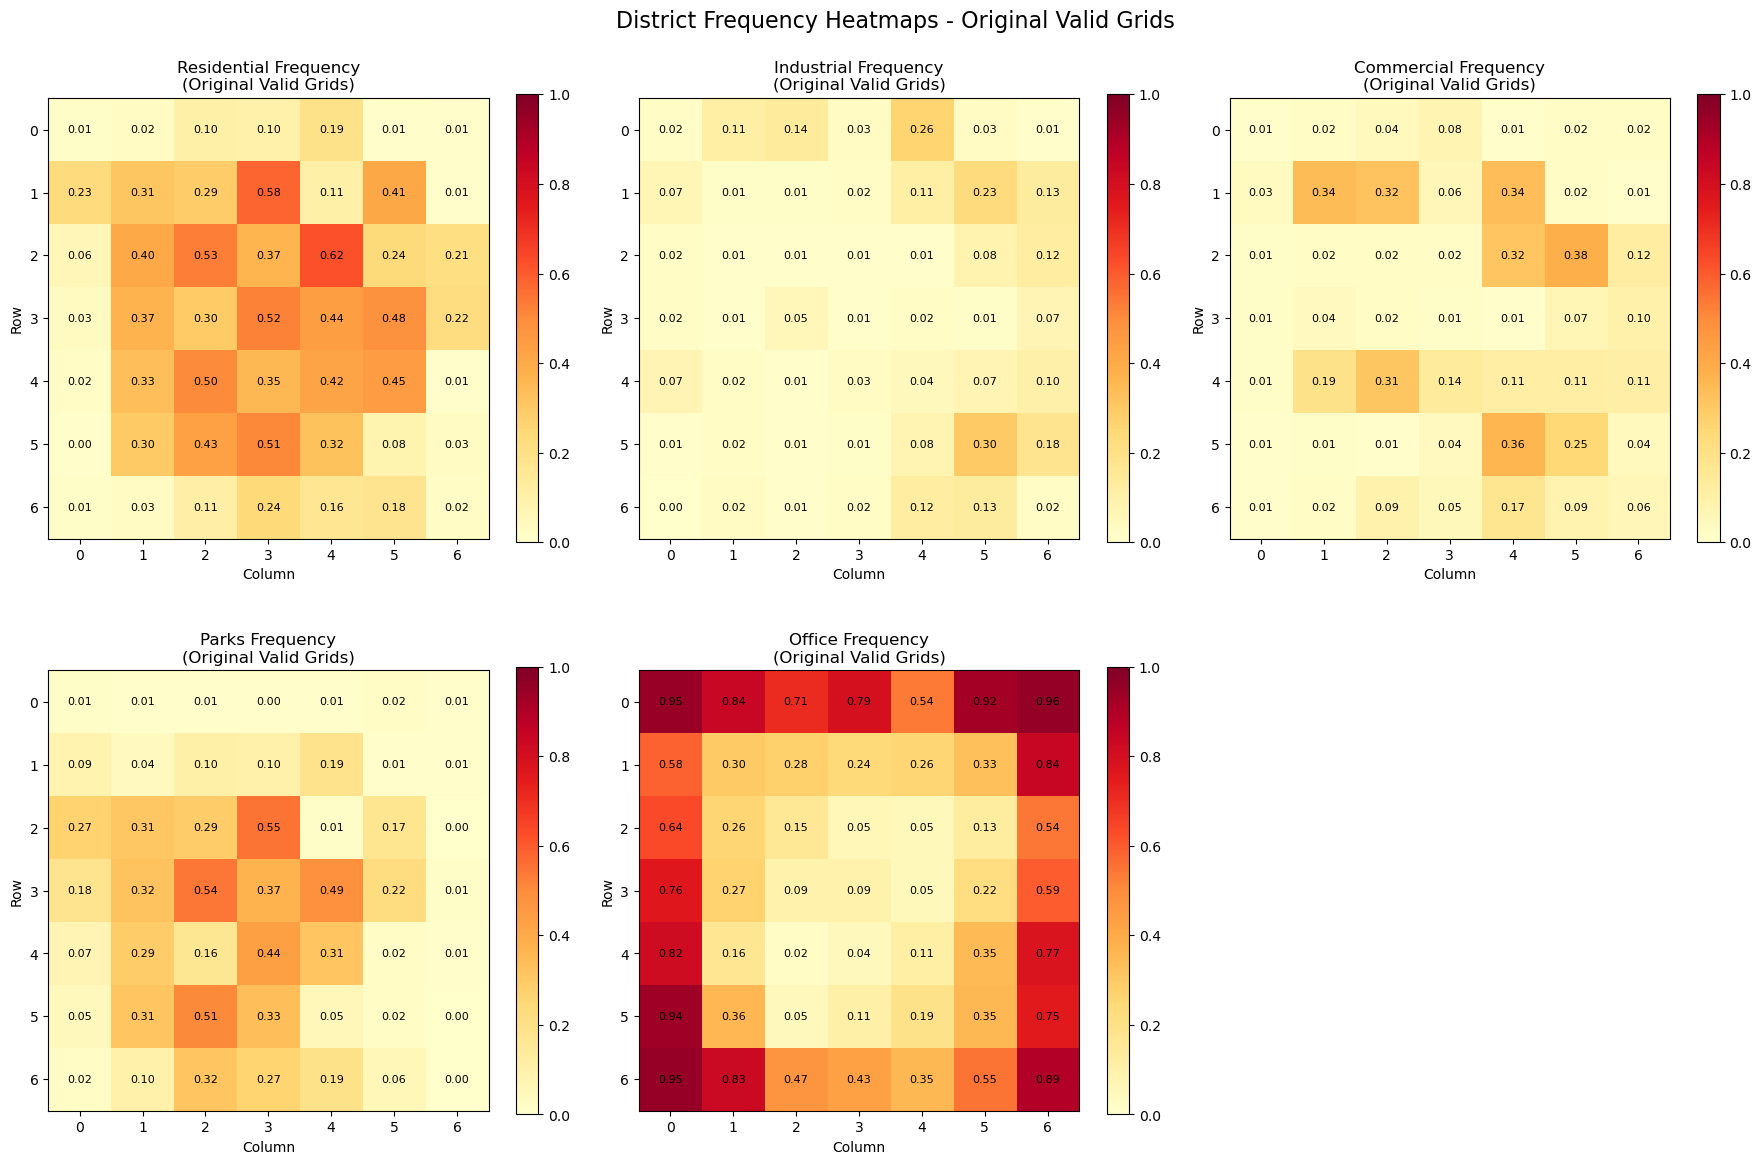


🗺️ Heatmaps for: Bias-Free Generated


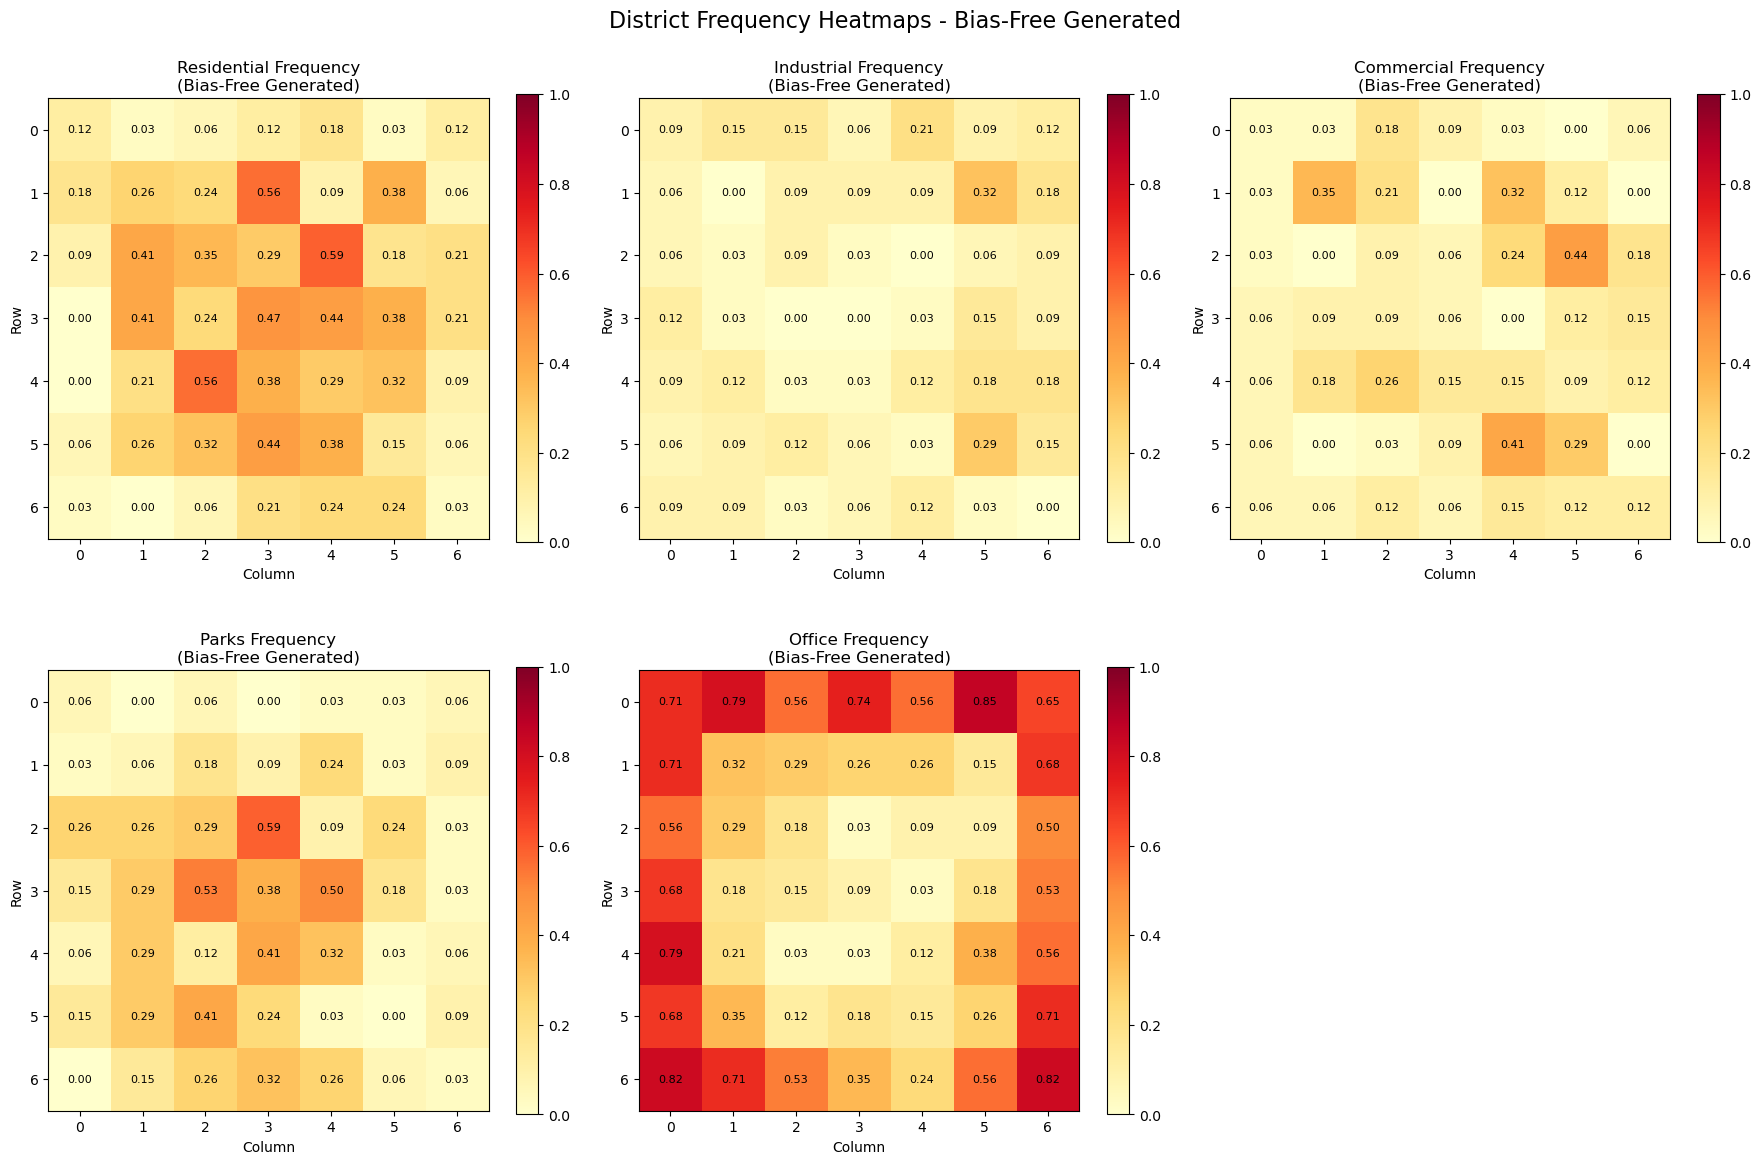


✅ HEATMAP ANALYSIS COMPLETE!
💡 Datasets analyzed:
   • Original Valid Grids: 49 positions analyzed
   • Bias-Free Generated: 49 positions analyzed
📊 Each dataset shows district type frequency (0.0-1.0) at each grid position


In [3]:
import pandas as pd

# � DISTRICT FREQUENCY HEATMAP ANALYSIS
print("📊 District Frequency Heatmap Analysis")
print("=" * 45)

def analyze_grid_position_frequencies(grids, grid_name="grids"):
    """
    Create a DataFrame with 49 rows (one per grid position) and 5 columns (one per district type)
    showing the frequency of each district type at each position
    """
    print(f"🔍 Analyzing position frequencies for {len(grids):,} {grid_name}...")
    
    # District type names
    district_types = ['Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
    
    # Initialize frequency data
    position_frequencies = []
    
    # Process each position (7x7 = 49 positions)
    for i in range(7):
        for j in range(7):
            position_name = f"pos_{i}_{j}"  # Row i, Column j
            position_index = i * 7 + j  # Linear index (0-48)
            
            # Extract values at this position across all grids
            position_values = grids[:, i, j]
            
            # Count frequency of each district type
            frequencies = {}
            total_grids = len(grids)
            
            for district_type in range(5):  # 0-4 for the 5 district types
                count = np.sum(position_values == district_type)
                frequency = count / total_grids
                frequencies[district_types[district_type]] = frequency
            
            # Add position info
            frequencies['Position'] = position_name
            frequencies['Row'] = i
            frequencies['Col'] = j
            frequencies['Linear_Index'] = position_index
            
            position_frequencies.append(frequencies)
    
    # Create DataFrame
    df = pd.DataFrame(position_frequencies)
    
    # Reorder columns for better readability
    column_order = ['Position', 'Row', 'Col', 'Linear_Index', 
                   'Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
    df = df[column_order]
    
    print(f"✅ Created frequency analysis DataFrame: {df.shape}")
    print(f"   49 positions × {len(district_types)} district types")
    print(f"   Each frequency represents proportion (0.0 - 1.0)")
    
    # Summary statistics
    print(f"\n📈 FREQUENCY SUMMARY:")
    for district in district_types:
        mean_freq = df[district].mean()
        std_freq = df[district].std()
        min_freq = df[district].min()
        max_freq = df[district].max()
        
        print(f"   {district:<12}: Mean={mean_freq:.3f}, Std={std_freq:.3f}, "
              f"Range=[{min_freq:.3f}, {max_freq:.3f}]")
    
    return df

def create_position_heatmap(df, district_type, title_suffix=""):
    """Create a 7x7 heatmap showing frequency of a district type at each position"""
    heatmap_data = np.zeros((7, 7))
    
    for _, row in df.iterrows():
        i, j = int(row['Row']), int(row['Col'])
        heatmap_data[i, j] = row[district_type]
    
    return heatmap_data

# Analyze different grid datasets
datasets_to_analyze = []

# 1. Analyze valid grids (if available)
if 'valid_original' in locals() and len(valid_original) > 0:
    print("\n1️⃣ ORIGINAL VALID GRIDS:")
    df_original_valid = analyze_grid_position_frequencies(valid_original, "original valid grids")
    datasets_to_analyze.append(('Original Valid Grids', df_original_valid))

# 2. Analyze bias-free grids
if 'valid_generated' in locals() and len(valid_generated) > 0:
    print("\n2️⃣ GENERATED VALID GRIDS:")
    df_bias_free = analyze_grid_position_frequencies(valid_generated, "valid_generated")
    datasets_to_analyze.append(('Bias-Free Generated', df_bias_free))

# 3. Compare corner positions if multiple datasets available
if len(datasets_to_analyze) > 1:
    print(f"\n🔄 DATASET COMPARISON:")
    print("="*60)
    
    # Compare key positions
    corner_positions = [(0, 0), (0, 6), (6, 0), (6, 6)]  # Four corners
    edge_positions = [(0, 3), (3, 0), (3, 6), (6, 3)]   # Mid-edges
    center_position = [(3, 3)]                            # Center
    
    positions_to_compare = {
        'Corners': corner_positions,
        'Edges': edge_positions, 
        'Center': center_position
    }
    
    for position_group, positions in positions_to_compare.items():
        print(f"\n📍 {position_group.upper()} COMPARISON:")
        
        for pos_row, pos_col in positions:
            linear_idx = pos_row * 7 + pos_col
            print(f"\n   Position ({pos_row},{pos_col}) - Linear Index {linear_idx}:")
            
            for dataset_name, df in datasets_to_analyze:
                row_data = df[df['Linear_Index'] == linear_idx].iloc[0]
                print(f"     {dataset_name:<20}: Res={row_data['Residential']:.2f} "
                      f"Ind={row_data['Industrial']:.2f} Com={row_data['Commercial']:.2f} "
                      f"Parks={row_data['Parks']:.2f} Office={row_data['Office']:.2f}")

# 4. Create heatmaps for visualization
if datasets_to_analyze:
    print(f"\n🎨 Creating district frequency heatmaps...")
    
    # Create heatmaps for each dataset
    for dataset_idx, (dataset_name, df_to_plot) in enumerate(datasets_to_analyze):
        print(f"\n🗺️ Heatmaps for: {dataset_name}")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        district_types = ['Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
        
        for idx, district in enumerate(district_types):
            heatmap_data = create_position_heatmap(df_to_plot, district)
            
            im = axes[idx].imshow(heatmap_data, cmap='YlOrRd', vmin=0, vmax=1)
            axes[idx].set_title(f'{district} Frequency\n({dataset_name})', fontsize=12)
            axes[idx].set_xlabel('Column')
            axes[idx].set_ylabel('Row')
            
            # Add frequency values as text
            for i in range(7):
                for j in range(7):
                    text = axes[idx].text(j, i, f'{heatmap_data[i, j]:.2f}',
                                        ha="center", va="center", color="black", fontsize=8)
            
            # Add colorbar
            plt.colorbar(im, ax=axes[idx], shrink=0.8)
        
        # Remove the extra subplot
        fig.delaxes(axes[5])
        
        plt.suptitle(f'District Frequency Heatmaps - {dataset_name}', fontsize=16)
        plt.tight_layout()
        plt.show()

print(f"\n✅ HEATMAP ANALYSIS COMPLETE!")
if datasets_to_analyze:
    print(f"💡 Datasets analyzed:")
    for name, df in datasets_to_analyze:
        print(f"   • {name}: {df.shape[0]} positions analyzed")
    print(f"📊 Each dataset shows district type frequency (0.0-1.0) at each grid position")
else:
    print("⚠️ No valid datasets available for heatmap analysis")